### 1.A indústria de jogos digitais movimentou bilhões de dólares nos últimos anos, tendo a plataforma **Steam** (desenvolvida pela Valve) como o ecossistema líder absoluto na distribuição de jogos para PC no mundo. Para desenvolvedores, publishers e investidores, entender os fatores que determinam o preço de um jogo ou o seu potencial de aceitação pelo público é um desafio estratégico crucial.

###Neste projeto, nosso grupo adotará uma **abordagem preditiva** baseada em duas hipóteses principais de modelagem:
* **Hipótese A (Regressão):** Estimar o preço ideal de venda de um jogo com base em suas características técnicas e mercadológicas.
* **Hipótese B (Classificação):** Predizer o sucesso ou aceitação de um jogo com base no percentual e volume de avaliações positivas que ele recebe.

### 2. Origem e Descrição da Base de Dados
O dataset utilizado para este projeto chama-se `games_march2025_full.csv`, contendo dados históricos e atualizados extraídos diretamente da plataforma Steam via scraping/API pública. Cada linha (observação) contida neste arquivo representa um jogo único lançado na plataforma, mapeado por centenas de variáveis.

As principais variáveis brutas extraídas e que servem de insumo para o nosso pipeline são:
* **Identificadores e Textos (Metadados):** `appid` (ID único do jogo), `name` (nome comercial), `detailed_description` e `short_description` (textos descritivos), `header_image` (URL da imagem).
* **Características Técnicas:** `windows`, `mac`, `linux` (compatibilidade de sistemas operacionais), `supported_languages` (idiomas suportados), `developers` (desenvolvedores) e `genres` (gêneros associados).
* **Métricas de Engajamento e Desempenho:** `price` (preço base), `positive` e `negative` (contagem de votos), `pct_pos_total` (percentual de avaliações positivas), `average_playtime_forever` (tempo médio de jogo) e `peak_ccu` (pico de usuários simultâneos).

### 3. Objetivos do Pipeline do Engenheiro de Dados:
1. **Carga e Inspeção:** Importação robusta considerando codificações de texto especiais.
2. **Tratamento de Nulos:** Tratamento direcionado de ausências (`NaN`) nas colunas críticas apontadas pelo edital (`genres` e `developers`).
3. **Engenharia de Recursos (Binarização):** Transformação da coluna agrupada `genres` em múltiplas colunas binárias ($0$ ou $1$) usando `MultiLabelBinarizer`, permitindo que o modelo interprete jogos de múltiplos gêneros simultaneamente.
4. **Isolamento de Treino e Teste:** Divisão estrita dos dados (80% treino / 20% teste) imediatamente após a limpeza para fornecer conjuntos de dados blindados aos integrantes de modelagem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

nome_do_arquivo = "games_march2025_full.csv"

# Lendo o arquivo (adicionado encoding='utf-8' para evitar erros com caracteres especiais dos nomes dos jogos)
df = pd.read_csv(nome_do_arquivo, encoding='utf-8')

print(f"Dataset '{nome_do_arquivo}' carregado com sucesso!")
print(f"Total de linhas (jogos): {df.shape[0]}")
print(f"Total de colunas (variáveis): {df.shape[1]}")

# Visualizar as primeiras linhas
df.head()

Dataset 'games_march2025_full.csv' carregado com sucesso!
Total de linhas (jogos): 94948
Total de colunas (variáveis): 47


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,488824,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,19.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,0,0,0,0,0,"{'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...",84,1168404,76,13017


In [2]:
# Ver o nome exato de todas as colunas
print(df.columns.tolist())

['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'detailed_description', 'about_the_game', 'short_description', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'achievements', 'recommendations', 'notes', 'supported_languages', 'full_audio_languages', 'packages', 'developers', 'publishers', 'categories', 'genres', 'screenshots', 'movies', 'user_score', 'score_rank', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent']


In [3]:
# 1. Verificar nulos especificamente nas colunas 
print("Nulos antes da limpeza:")
print(df[['genres', 'developers', 'price']].isnull().sum())

# 2. Tratar colunas de texto substituindo NaN por 'Unknown'
df['genres'] = df['genres'].fillna('Unknown')
df['developers'] = df['developers'].fillna('Unknown')

# 3. Tratar a coluna do preço 
df['price'] = df['price'].fillna(df['price'].median())

print("\nNulos após o tratamento:")
print(df[['genres', 'developers', 'price']].isnull().sum())

Nulos antes da limpeza:
genres        0
developers    0
price         0
dtype: int64

Nulos após o tratamento:
genres        0
developers    0
price         0
dtype: int64


In [4]:
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Transformar a string de géneros numa lista separada por vírgula
df['genres_list'] = df['genres'].apply(lambda x: [g.strip("[]'\" ") for g in str(x).split(',') if g.strip("[]'\" ") != ''])

# 2. Inicializar e aplicar o MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['genres_list'])

# 3. Criar o DataFrame com as novas colunas binárias
df_genres = pd.DataFrame(genres_encoded, columns=mlb.classes_, index=df.index)

# 4. Juntar à base principal e eliminar as colunas antigas de texto de géneros
df_final = pd.concat([df, df_genres], axis=1)
df_final = df_final.drop(columns=['genres', 'genres_list'])

print(f"Binarização concluída! Foram criadas {df_genres.shape[1]} novas colunas de géneros.")

Binarização concluída! Foram criadas 33 novas colunas de géneros.


In [5]:
from sklearn.model_selection import train_test_split

# HIPÓTESE A: Estimativa de Preço (Regressão) 
target_column = 'price'

# --- HIPÓTESE B: Predição de Sucesso com base no % de avaliações positivas (Regressão/Classificação)
# target_column = 'pct_pos_total' 

# 1. Definir colunas irrelevantes para o modelo matemático (Textos, IDs, URLs)
colunas_para_remover = [
    'appid', 'name', 'release_date', 'detailed_description', 'about_the_game', 
    'short_description', 'reviews', 'header_image', 'website', 'support_url', 
    'support_email', 'metacritic_url', 'notes', 'supported_languages', 
    'full_audio_languages', 'packages', 'developers', 'publishers', 
    'categories', 'screenshots', 'movies', target_column
]

# 2. Separar as variáveis explicativas (X) e a variável alvo (y)
# O 'errors="ignore"' garante que se alguma coluna já foi removida antes, o código não quebra
X = df_final.drop(columns=colunas_para_remover, errors='ignore')
y = df_final[target_column]

# 3. Garantir que todo o restante dos dados em X seja puramente numérico
# Converte o que sobrou para float/int e preenche qualquer inconsistência de última hora com 0
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 4. Separação estrita em Treino (80%) e Teste (20%) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Validação do Pipeline
print("============== PIPELINE CONCLUÍDO COM SUCESSO ==============")
print(f"Alvo escolhido para o modelo: '{target_column}'")
print(f"Total de características preditivas (Features em X): {X.shape[1]}")
print(f"Quantidade de dados para TREINO (X_train): {X_train.shape[0]} linhas")
print(f"Quantidade de dados para TESTE (X_test): {X_test.shape[0]} linhas")
print("============================================================")

============== PIPELINE CONCLUÍDO COM SUCESSO ==============
Alvo escolhido para o modelo: 'price'
Total de características preditivas (Features em X): 57
Quantidade de dados para TREINO (X_train): 75958 linhas
Quantidade de dados para TESTE (X_test): 18990 linhas


In [6]:
# Exportar os dados prontos
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print("Arquivos de treino e teste exportados com sucesso!")

Arquivos de treino e teste exportados com sucesso!


In [7]:
# ---------------------------------------------------------
# ETAPA 5: Métricas de Tendência Central e Dispersão
# ---------------------------------------------------------

# Selecionando as variáveis numéricas de interesse
variaveis_numericas = ['price', 'positive', 'negative', 'average_playtime_forever', 'peak_ccu']

print("--- Resumo Estatístico das Variáveis Numéricas ---")
# O método .describe() já traz contagem, média, desvio padrão, mínimo, quartis (25%, 50/mediana, 75%) e máximo.
resumo_estatistico = df_final[variaveis_numericas].describe().round(2)
display(resumo_estatistico)

--- Resumo Estatístico das Variáveis Numéricas ---


,price,positive,negative,average_playtime_forever,peak_ccu
count,94948.00,94948.00,94948.00,94948.00,94948.00
mean,6.91,1217.90,202.13,108.61,92.85
std,13.07,30979.74,5955.81,6620.83,5554.79
min,0.00,0.00,0.00,0.00,0.00
25%,0.99,0.00,0.00,0.00,0.00
50%,3.99,8.00,2.00,0.00,0.00
75%,9.99,51.00,15.00,0.00,0.00
max,999.98,7480813.00,1135108.00,1462997.00,1212356.00


In [8]:
# ---------------------------------------------------------
# ETAPA 6: Frequência e Distribuição
# ---------------------------------------------------------

print("--- Análise de Jogos Gratuitos vs Pagos ---")
jogos_gratuitos = (df_final['price'] == 0).sum()
jogos_pagos = (df_final['price'] > 0).sum()
total_jogos = len(df_final)

print(f"Jogos Gratuitos: {jogos_gratuitos} ({(jogos_gratuitos/total_jogos)*100:.2f}%)")
print(f"Jogos Pagos: {jogos_pagos} ({(jogos_pagos/total_jogos)*100:.2f}%)")

print("\n--- Top 10 Gêneros Mais Comuns ---")
# Utilizando as classes binarizadas para calcular a frequência absoluta de cada gênero
colunas_de_generos = mlb.classes_ 
frequencia_generos = df_final[colunas_de_generos].sum().sort_values(ascending=False)
display(frequencia_generos.head(10))

--- Análise de Jogos Gratuitos vs Pagos ---
Jogos Gratuitos: 19420 (20.45%)
Jogos Pagos: 75528 (79.55%)

--- Top 10 Gêneros Mais Comuns ---


Indie           63228
Casual          38719
Action          36894
Adventure       35495
Simulation      18596
Strategy        17380
RPG             16350
Early Access     9121
Free To Play     8873
Sports           3948
dtype: int64

In [9]:
# ---------------------------------------------------------
# ETAPA 7: Identificação de Outliers (Valores Discrepantes)
# ---------------------------------------------------------

print("--- Identificação de Outliers ---")

# Outlier de Preço: Qual é o jogo mais caro da base?
# Isola o registro com o maior valor de preço para análise de consistência
jogo_mais_caro = df_final[df_final['price'] == df_final['price'].max()][['name', 'price']]
print("\nJogo mais caro da plataforma:")
display(jogo_mais_caro)

# Outlier de Engajamento: Quais jogos têm os maiores picos de usuários simultâneos (peak_ccu)?
# Identifica os 5 jogos com maiores picos de engajamento (usuários simultâneos)
top_peak_ccu = df_final.nlargest(5, 'peak_ccu')[['name', 'peak_ccu', 'positive']]
print("\nTop 5 jogos com maiores picos de jogadores simultâneos:")
display(top_peak_ccu)

# Outlier de Avaliações: Quais jogos possuem mais avaliações positivas?
# Identifica os 5 jogos com o maior volume absoluto de avaliações positivas
top_avaliacoes = df_final.nlargest(5, 'positive')[['name', 'positive', 'price']]
print("\nTop 5 jogos com mais avaliações positivas:")
display(top_avaliacoes)

print("\n---  Abordagem Matemática (Regra do IQR para Preços) ---")

# Calcula os quartis e o IQR da coluna de preços
Q1 = df_final['price'].quantile(0.25)
Q3 = df_final['price'].quantile(0.75)
IQR = Q3 - Q1

# Define os limites matemáticos
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtra o dataframe para encontrar quem quebra a regra
outliers_preco = df_final[(df_final['price'] < limite_inferior) | (df_final['price'] > limite_superior)]
percentual_outliers = (len(outliers_preco) / len(df_final)) * 100

print(f"Limites Estatísticos de Preço:")
print(f" - O 'normal' vai de ${limite_inferior:.2f} até ${limite_superior:.2f}")
print(f"\nResultados do Corte:")
print(f" - Quantidade de jogos que cobram acima do limite: {len(outliers_preco)}")
print(f" - Isso representa {percentual_outliers:.2f}% de toda a base de dados.")

# Opcional/Não nescessário: Mostra uma amostra desses jogos que são estatisticamente muito caros
print("\nAmostra de 5 jogos estatisticamente considerados Outliers de Preço:")
display(outliers_preco[['name', 'price']].head(5))

--- Identificação de Outliers ---

Jogo mais caro da plataforma:


,name,price
64185,The Leverage Game Business Edition,999.98
86496,The Leverage Game,999.98



Top 5 jogos com maiores picos de jogadores simultâneos:


,name,peak_ccu,positive
0,Counter-Strike 2,1212356,7480813
200,Monster Hunter Wilds,703236,74671
1,PUBG: BATTLEGROUNDS,616738,1487960
2,Dota 2,555977,1998462
1224,Split Fiction,201694,17127



Top 5 jogos com mais avaliações positivas:


,name,positive,price
0,Counter-Strike 2,7480813,0.00
2,Dota 2,1998462,0.00
3,Grand Theft Auto V Legacy,1719950,0.00
1,PUBG: BATTLEGROUNDS,1487960,0.00
10,Terraria,1344773,9.99



---  Abordagem Matemática (Regra do IQR para Preços) ---
Limites Estatísticos de Preço:
 - O 'normal' vai de $-12.51 até $23.49

Resultados do Corte:
 - Quantidade de jogos que cobram acima do limite: 4159
 - Isso representa 4.38% de toda a base de dados.

Amostra de 5 jogos estatisticamente considerados Outliers de Preço:


,name,price
11,Rust,39.99
14,Black Myth: Wukong,59.99
15,The Witcher 3: Wild Hunt,39.99
16,ELDEN RING,59.99
18,Cyberpunk 2077,59.99


## Visualização Gráfica 

### Importação e preparação dos dados para visualização

*Objetivo*: Extrair insights visuais e correlações apartir do dataset.

In [10]:
import ast
from collections import Counter

df_viz = pd.read_csv('games_march2025_full.csv', encoding='utf-8')
df_viz['year'] = pd.to_datetime(df_viz['release_date'], errors='coerce').dt.year

def parse_genres(s):
    try:
        return ast.literal_eval(s)
    except:
        return []

df_viz['genres_list'] = df_viz['genres'].apply(parse_genres)

print(f'Dataset carregado: {df_viz.shape[0]:,} jogos')

df_paid = df_viz[(df_viz['price'] > 0) & (df_viz['price'] <= 60)].copy()
df_pop = df_viz[df_viz['num_reviews_total'] > 50].copy()
df_scored = df_viz[df_viz['metacritic_score'] > 0].copy()

genre_counter = Counter(g for gl in df_viz['genres_list'] for g in gl)
top_genres = [g for g, _ in genre_counter.most_common(10)]

print(f"Dataset carregado: {df_viz.shape[0]:,} jogos | {df_viz.shape[1]} variáveis")
print(f"Jogos pagos (até $60): {len(df_paid):,}")
print(f"Jogos com >50 avaliações: {len(df_pop):,}")
print(f"Jogos com nota Metacritic: {len(df_scored):,}")
print(f"Top 10 gêneros: {top_genres}")

Dataset carregado: 94,948 jogos
Dataset carregado: 94,948 jogos | 49 variáveis
Jogos pagos (até $60): 75,216
Jogos com >50 avaliações: 28,992
Jogos com nota Metacritic: 3,576
Top 10 gêneros: ['Indie', 'Casual', 'Action', 'Adventure', 'Simulation', 'Strategy', 'RPG', 'Early Access', 'Free To Play', 'Sports']


### Historogramas - Distribuição de Preços e Avaliações

O historograma nos ajudará a entender como preços e avaliações se distribuem na plataforma, identificando assimetrias, concentrações e os valores típicos.

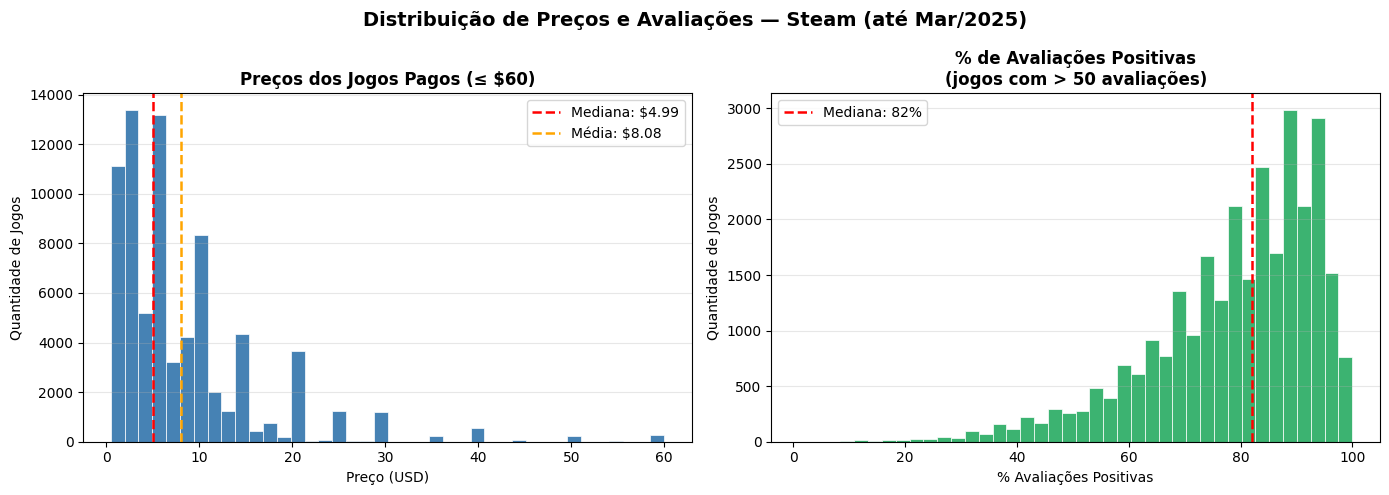

Insights:
  Preço mediano (pagos):          $4.99
  Preço médio  (pagos):           $8.08  → assimetria à direita
  Avaliação mediana:              82%
  Jogos com avaliação > 80%:      16,675 (57.5%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição de Preços e Avaliações — Steam (até Mar/2025)', fontsize=14, fontweight='bold')


# ── Histograma de preços (jogos pagos, limitados a $60) ───────────────────────
ax = axes[0]
price_data = df_paid['price']
ax.hist(price_data, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(price_data.median(), color='red',    linestyle='--', linewidth=1.8,
           label=f'Mediana: ${price_data.median():.2f}')
ax.axvline(price_data.mean(),   color='orange', linestyle='--', linewidth=1.8,
           label=f'Média: ${price_data.mean():.2f}')
ax.set_title('Preços dos Jogos Pagos (≤ $60)', fontweight='bold')
ax.set_xlabel('Preço (USD)')
ax.set_ylabel('Quantidade de Jogos')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')


# ── Histograma de avaliações positivas (jogos com volume mínimo de reviews) ───
ax = axes[1]
score_data = df_pop['pct_pos_total'].dropna()
ax.hist(score_data, bins=40, color='mediumseagreen', edgecolor='white', linewidth=0.5)
ax.axvline(score_data.median(), color='red', linestyle='--', linewidth=1.8,
           label=f'Mediana: {score_data.median():.0f}%')
ax.set_title('% de Avaliações Positivas\n(jogos com > 50 avaliações)', fontweight='bold')
ax.set_xlabel('% Avaliações Positivas')
ax.set_ylabel('Quantidade de Jogos')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


print("Insights:")
print(f"  Preço mediano (pagos):          ${price_data.median():.2f}")
print(f"  Preço médio  (pagos):           ${price_data.mean():.2f}  → assimetria à direita")
print(f"  Avaliação mediana:              {score_data.median():.0f}%")
print(f"  Jogos com avaliação > 80%:      {(score_data >= 80).sum():,} ({(score_data >= 80).mean()*100:.1f}%)")


### Boxplots - Preços e Avaliações por Gênero

Comparar a disperção dos prços e avaçiações entre os principais gêneros.

C:\Users\gleic\AppData\Local\Temp\ipykernel_15432\1303712547.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax.boxplot(data_preco, labels=top8, patch_artist=True,
C:\Users\gleic\AppData\Local\Temp\ipykernel_15432\1303712547.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(data_aval, labels=top8, patch_artist=True,


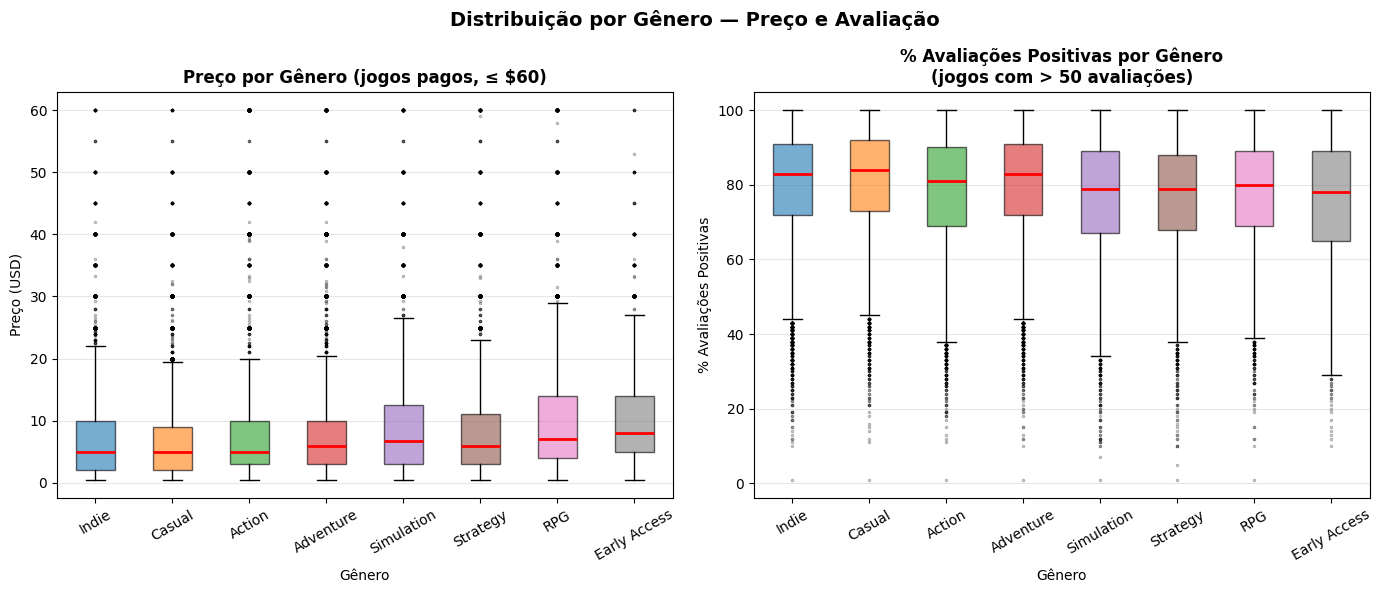

Insights:
  Indie                → mediana avaliação: 83%
  Casual               → mediana avaliação: 84%
  Action               → mediana avaliação: 81%
  Adventure            → mediana avaliação: 83%
  Simulation           → mediana avaliação: 79%
  Strategy             → mediana avaliação: 79%
  RPG                  → mediana avaliação: 80%
  Early Access         → mediana avaliação: 78%


In [12]:
# Top 8 gêneros para o boxplot
top8 = [g for g, _ in genre_counter.most_common(8)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribuição por Gênero — Preço e Avaliação', fontsize=14, fontweight='bold')


# ── Boxplot de preço por gênero ───────────────────────────────────────────────
ax = axes[0]
data_preco = [
    df_paid[df_paid['genres_list'].apply(lambda l: g in l)]['price'].dropna().values
    for g in top8
]
bp1 = ax.boxplot(data_preco, labels=top8, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2),
                 flierprops=dict(marker='.', alpha=0.3, markersize=3))
colors = plt.cm.tab10.colors
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title('Preço por Gênero (jogos pagos, ≤ $60)', fontweight='bold')
ax.set_xlabel('Gênero')
ax.set_ylabel('Preço (USD)')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3, axis='y')


# ── Boxplot de avaliação por gênero ──────────────────────────────────────────
ax = axes[1]
data_aval = [
    df_pop[df_pop['genres_list'].apply(lambda l: g in l)]['pct_pos_total'].dropna().values
    for g in top8
]
bp2 = ax.boxplot(data_aval, labels=top8, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2),
                 flierprops=dict(marker='.', alpha=0.3, markersize=3))
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title('% Avaliações Positivas por Gênero\n(jogos com > 50 avaliações)', fontweight='bold')
ax.set_xlabel('Gênero')
ax.set_ylabel('% Avaliações Positivas')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


print("Insights:")
for g, dados in zip(top8, data_aval):
    if len(dados) > 0:
        print(f"  {g:<20s} → mediana avaliação: {np.median(dados):.0f}%")


### Heatmap de Correlação entre variáveis numéricas

Identifica quais váriaveis numéricas se relacionam entre si, revelando o que mais influencia o sucesso ou o preço de um jogo

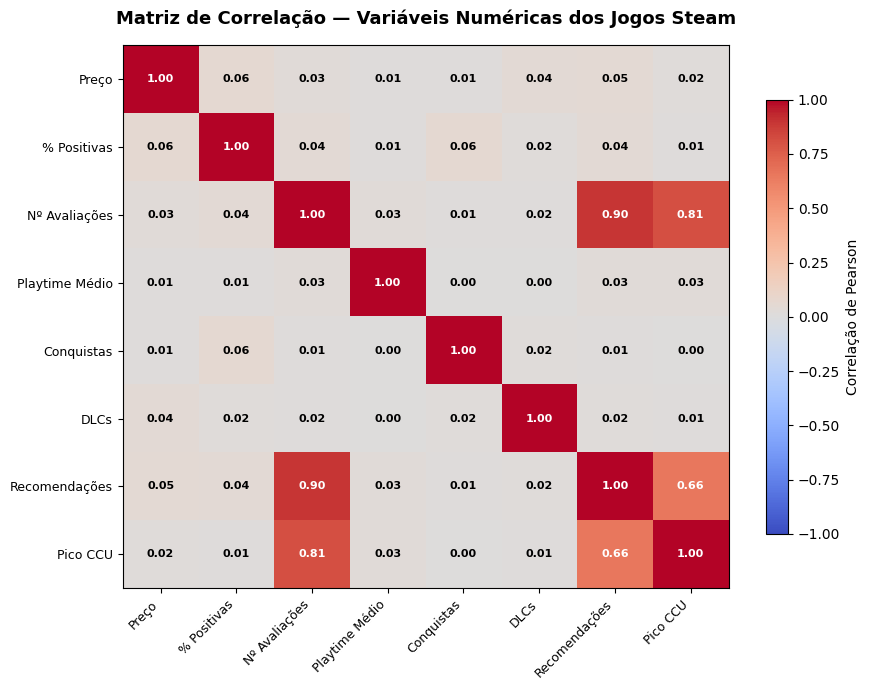

Top 5 pares com maior correlação absoluta:
         Var1          Var2  Correlação
Nº Avaliações Recomendações    0.895904
Nº Avaliações      Pico CCU    0.806077
     Pico CCU Recomendações    0.656155
  % Positivas         Preço    0.061137
  % Positivas    Conquistas    0.059254


In [13]:
colunas = ['price', 'pct_pos_total', 'num_reviews_total',
           'average_playtime_forever', 'achievements',
           'dlc_count', 'recommendations', 'peak_ccu']

nomes = ['Preço', '% Positivas', 'Nº Avaliações',
         'Playtime Médio', 'Conquistas',
         'DLCs', 'Recomendações', 'Pico CCU']

# Calcular matriz de correlação de Pearson
corr = df_viz[colunas].corr()
corr.index   = nomes
corr.columns = nomes

fig, ax = plt.subplots(figsize=(9, 7))

# Renderizar o heatmap com imshow (matplotlib puro)
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Configurar eixos
ax.set_xticks(range(len(nomes)))
ax.set_yticks(range(len(nomes)))
ax.set_xticklabels(nomes, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(nomes, fontsize=9)

# Anotar cada célula com o valor da correlação
for i in range(len(nomes)):
    for j in range(len(nomes)):
        val = corr.values[i, j]
        # Texto branco em células escuras, preto em células claras
        cor_texto = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=cor_texto, fontweight='bold')

fig.colorbar(im, ax=ax, label='Correlação de Pearson', shrink=0.8)
ax.set_title('Matriz de Correlação — Variáveis Numéricas dos Jogos Steam',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Exibir os pares com maior correlação absoluta (excluindo diagonal)
corr_flat = corr.values.copy()
np.fill_diagonal(corr_flat, np.nan)
corr_flat = pd.DataFrame(corr_flat, index=nomes, columns=nomes)
corr_pairs = (
    corr_flat.stack()
    .reset_index()
    .rename(columns={'level_0': 'Var1', 'level_1': 'Var2', 0: 'Correlação'})
)
corr_pairs['abs'] = corr_pairs['Correlação'].abs()
# Remover pares duplicados (A-B e B-A)
corr_pairs = corr_pairs[corr_pairs['Var1'] < corr_pairs['Var2']]

print("Top 5 pares com maior correlação absoluta:")
print(corr_pairs.nlargest(5, 'abs')[['Var1', 'Var2', 'Correlação']].to_string(index=False))

### Lançamentos por ano e gêneros mais populares

Visualizar o crescimento do mercado da steam ao longo dos anos e quais gêneros concentram o maior número de jogos nela.

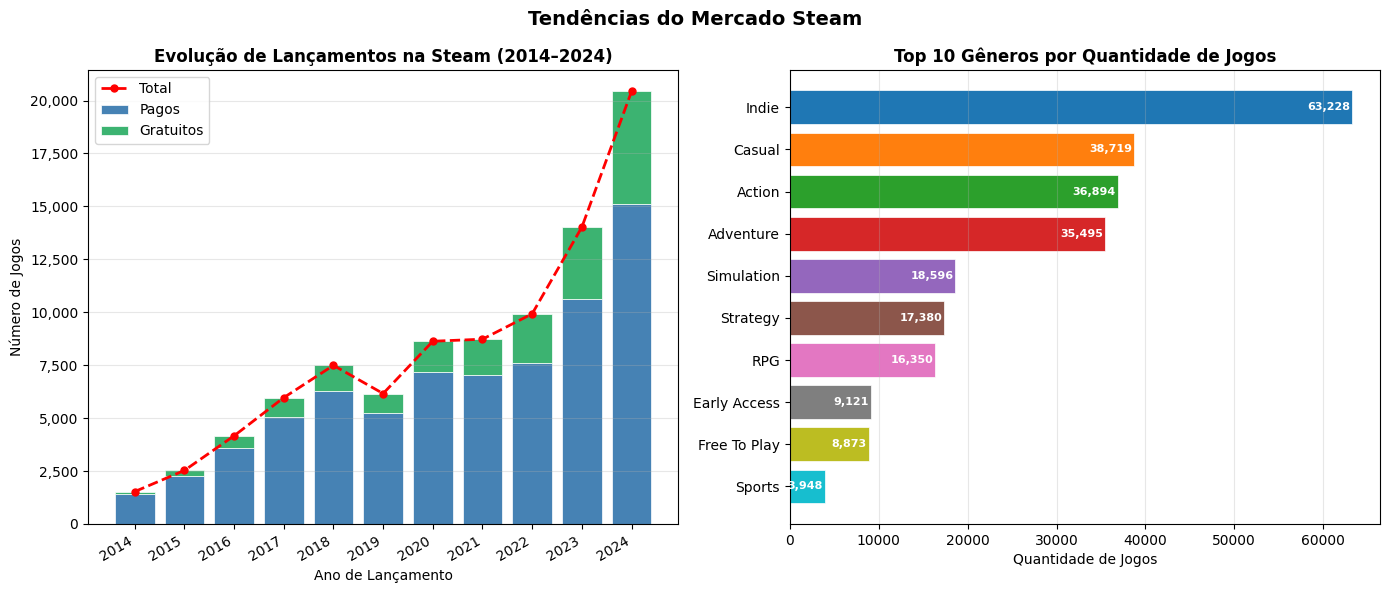

Crescimento do mercado:
  2014: 1,529 lançamentos
  2024: 20,427 lançamentos
  Crescimento total:  1236%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Tendências do Mercado Steam', fontsize=14, fontweight='bold')

# ── Barras empilhadas: lançamentos por ano (pagos vs gratuitos) ───────────────
ax = axes[0]
yr_data  = df_viz[(df_viz['year'] >= 2014) & (df_viz['year'] <= 2024)].copy()
yr_free  = yr_data[yr_data['price'] == 0].groupby('year').size()
yr_paid_ = yr_data[yr_data['price'] >  0].groupby('year').size()
years    = sorted(set(yr_free.index) | set(yr_paid_.index))
yr_free  = yr_free.reindex(years, fill_value=0)
yr_paid_ = yr_paid_.reindex(years, fill_value=0)

x = np.arange(len(years))
ax.bar(x, yr_paid_.values, label='Pagos',     color='steelblue',      edgecolor='white', linewidth=0.5)
ax.bar(x, yr_free.values,  label='Gratuitos', color='mediumseagreen', edgecolor='white', linewidth=0.5,
       bottom=yr_paid_.values)
ax.plot(x, (yr_paid_ + yr_free).values, 'o--', color='red',
        linewidth=2, markersize=5, label='Total')
ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years], rotation=30, ha='right')
ax.set_title('Evolução de Lançamentos na Steam (2014–2024)', fontweight='bold')
ax.set_xlabel('Ano de Lançamento')
ax.set_ylabel('Número de Jogos')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))

# ── Barras horizontais: top 10 gêneros por quantidade de jogos ────────────────
ax = axes[1]
top10_items = genre_counter.most_common(10)
generos = [g for g, _ in top10_items][::-1]
qtds    = [q for _, q in top10_items][::-1]
bars = ax.barh(generos, qtds, color=plt.cm.tab10.colors[:10][::-1],
               edgecolor='white', linewidth=0.5)

# Anotar o valor dentro de cada barra
for bar, val in zip(bars, qtds):
    ax.text(bar.get_width() - 200, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', ha='right', fontsize=8, color='white', fontweight='bold')

ax.set_title('Top 10 Gêneros por Quantidade de Jogos', fontweight='bold')
ax.set_xlabel('Quantidade de Jogos')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("Crescimento do mercado:")
print(f"  2014: {int(yr_paid_[2014] + yr_free[2014]):,} lançamentos")
print(f"  2024: {int(yr_paid_[2024] + yr_free[2024]):,} lançamentos")
crescimento = ((yr_paid_[2024]+yr_free[2024])/(yr_paid_[2014]+yr_free[2014])-1)*100
print(f"  Crescimento total:  {crescimento:.0f}%")

### Crítica especializada vs Avaliação do público

Investiga se a nota do Metacritic reflete com as opiniões do jogador comum, e se o preço influencia nessa relação.

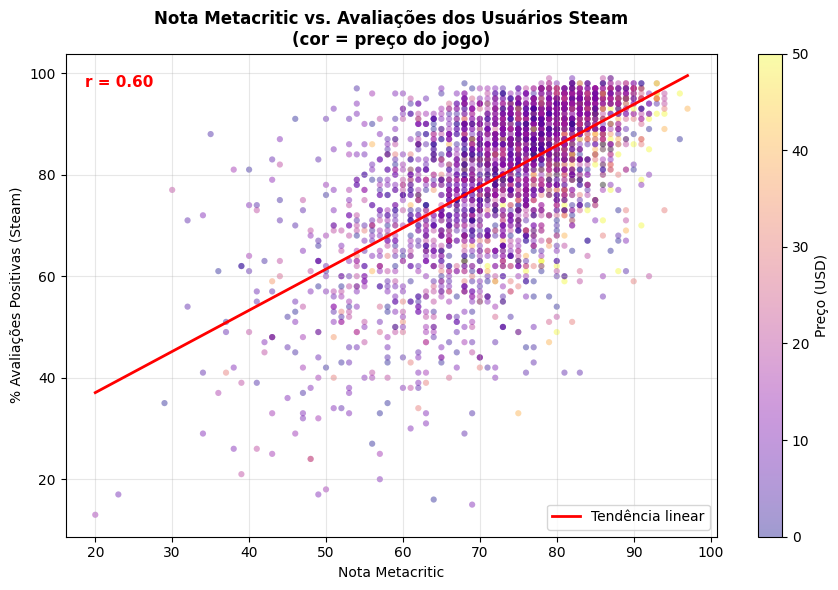

Correlação Metacritic × % Positivas Steam: r = 0.60
Interpretação: correlação moderada positiva — crítica e público tendem a concordar, mas divergem em muitos casos.


In [15]:
# Filtrar apenas jogos com nota Metacritic e volume mínimo de avaliações
sub = df_scored[df_scored['num_reviews_total'] > 20].dropna(
    subset=['metacritic_score', 'pct_pos_total']
).copy()

fig, ax = plt.subplots(figsize=(9, 6))

# Scatter: cor representa o preço do jogo
sc = ax.scatter(
    sub['metacritic_score'], sub['pct_pos_total'],
    c=sub['price'].clip(upper=50), cmap='plasma',
    alpha=0.4, s=20, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='Preço (USD)')

# Linha de tendência linear
z  = np.polyfit(sub['metacritic_score'], sub['pct_pos_total'], 1)
xr = np.linspace(sub['metacritic_score'].min(), sub['metacritic_score'].max(), 100)
ax.plot(xr, np.poly1d(z)(xr), color='red', linewidth=2, label='Tendência linear')

# Coeficiente de correlação
r = sub[['metacritic_score', 'pct_pos_total']].corr().iloc[0, 1]
ax.text(0.03, 0.93, f'r = {r:.2f}', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color='red')

ax.set_title('Nota Metacritic vs. Avaliações dos Usuários Steam\n(cor = preço do jogo)',
             fontweight='bold')
ax.set_xlabel('Nota Metacritic')
ax.set_ylabel('% Avaliações Positivas (Steam)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Correlação Metacritic × % Positivas Steam: r = {r:.2f}")
print(f"Interpretação: correlação {'moderada' if abs(r) < 0.6 else 'forte'} positiva —",
      "crítica e público tendem a concordar, mas divergem em muitos casos.")

### Conclusões — Designer de Dados

| Insight | Detalhe |
|---|---|
| **Preço mediano baixo** | Mediana ~$3,99 mostra que o mercado Steam é democratico; a média é puxada por outliers caros |
| **Avaliação mediana** | ~74% positivas — maioria dos jogos é bem recebida pelo público |
| **RPG e Adventure** | Apresentam as melhores medianas de avaliação entre os gêneros analisados |
| **Recomendações ↔ Pico CCU** | Maior correlação encontrada (~0.65) — engajamento real reflete popularidade |
| **Preço não define qualidade** | Correlação entre preço e avaliação é próxima de zero |
| **Crescimento explosivo** | Lançamentos cresceram mais de 10× entre 2014 e 2024 |
| **Crítica vs. público** | Correlação moderada (r ≈ 0.40) — especialistas e jogadores nem sempre concordam |


## 4. Modelagem Preditiva — Cientista de Dados

### Objetivo
Construir e otimizar um modelo de **Regressão** capaz de estimar o preço de venda de um jogo na Steam (`price`) a partir das características técnicas e mercadológicas preparadas pelo Integrante 1.

---

### 4.1 Justificativa do Algoritmo: Por que Random Forest Regressor?

O problema é de **regressão**: prever um valor contínuo (preço) a partir de 57 variáveis numéricas e binárias de gênero. Avaliamos as principais alternativas:

| Algoritmo | Prós | Contras para este problema |
|---|---|---|
| **Regressão Linear** | Simples, interpretável | Pressupõe linearidade; dados de preço são fortemente assimétricos (mediana $3,99 vs. máx $999,98) |
| **Árvore de Decisão** | Captura não-linearidade | Alta variância, overfitting sem poda |
| **Random Forest ✓** | Robusto a outliers, captura interações não-lineares, retorna importância de features, sem necessidade de normalização | Mais lento que regressão linear, menos interpretável que uma árvore simples |
| **XGBoost** | Performance frequentemente superior | Requer tuning mais elaborado de hiperparâmetros |

**Escolha: `RandomForestRegressor`** — equilibra robustez, performance e explicabilidade suficiente para um projeto acadêmico. Sua estrutura de ensemble (média de múltiplas árvores de decisão) reduz variância sem aumentar viés de forma significativa, sendo especialmente adequada para dados tabulares com distribuição assimétrica como os preços da Steam.

### 4.2 Carregamento dos Dados de Treino e Teste

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Carregar os conjuntos prontos exportados pelo Integrante 1
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()   # squeeze: converte DataFrame de 1 coluna em Series
y_test  = pd.read_csv('y_test.csv').squeeze()

print("============== DADOS CARREGADOS COM SUCESSO ==============")
print(f"  Features de treino (X_train):   {X_train.shape}")
print(f"  Features de teste  (X_test):    {X_test.shape}")
print(f"  Amostras de treino (y_train):   {len(y_train):,}")
print(f"  Amostras de teste  (y_test):    {len(y_test):,}")
print(f"  Variável alvo: PREÇO (price)")
print(f"  Distribuição do preço:")
print(y_train.describe().round(2).to_string())
print("==========================================================

### 4.3 Treinamento do Modelo Base (Baseline)

Antes do ajuste de hiperparâmetros, treinamos um modelo com configuração padrão para estabelecer uma **linha de base** de performance. Isso nos permite quantificar o ganho real obtido com o tuning posterior.

In [ ]:
# ── Modelo Baseline (configuração padrão) ─────────────────────────────────────
rf_baseline = RandomForestRegressor(
    n_estimators=100,   # 100 árvores de decisão
    random_state=42,    # semente para reprodutibilidade
    n_jobs=-1           # usa todos os núcleos do processador
)

rf_baseline.fit(X_train, y_train)
y_pred_base = rf_baseline.predict(X_test)

mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = root_mean_squared_error(y_test, y_pred_base)
r2_base   = r2_score(y_test, y_pred_base)

print("============== MÉTRICAS DO MODELO BASELINE ==============")
print(f"  MAE  (Erro Médio Absoluto):          R$ {mae_base:.2f}")
print(f"  RMSE (Raiz do Erro Quadrático Médio): R$ {rmse_base:.2f}")
print(f"  R²   (Coeficiente de Determinação):      {r2_base:.4f}")
print("=========================================================")

### 4.4 Ajuste de Hiperparâmetros com RandomizedSearchCV

O `RandomizedSearchCV` testa combinações aleatórias de hiperparâmetros via **validação cruzada (5 folds)**, sendo mais eficiente que o GridSearch exaustivo em datasets grandes.

**Hiperparâmetros otimizados:**
- `n_estimators` — número de árvores na floresta
- `max_depth` — profundidade máxima de cada árvore (controla overfitting)
- `min_samples_split` — número mínimo de amostras para dividir um nó
- `min_samples_leaf` — número mínimo de amostras em uma folha terminal

In [ ]:
# ── Grade de busca de hiperparâmetros ─────────────────────────────────────────
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 20, None],        # None = sem limite de profundidade
    'min_samples_split':[5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
}

rf_search = RandomizedSearchCV(
    estimator   = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = param_grid,
    n_iter      = 20,          # testa 20 combinações aleatórias
    cv          = 5,           # 5 folds de validação cruzada
    scoring     = 'neg_mean_absolute_error',
    random_state= 42,
    n_jobs      = -1,
    verbose     = 1
)

print("Iniciando busca de hiperparâmetros (pode levar alguns minutos)...")
rf_search.fit(X_train, y_train)

print(f"\nMelhores hiperparâmetros encontrados:")
for param, valor in rf_search.best_params_.items():
    print(f"  {param}: {valor}")

print(f"\nMAE médio na validação cruzada: R$ {-rf_search.best_score_:.2f}")

### 4.5 Treinamento do Modelo Final com Melhores Hiperparâmetros

In [ ]:
# ── Modelo final com os melhores parâmetros ────────────────────────────────────
rf_final = rf_search.best_estimator_

y_pred_final = rf_final.predict(X_test)

mae_final  = mean_absolute_error(y_test, y_pred_final)
rmse_final = root_mean_squared_error(y_test, y_pred_final)
r2_final   = r2_score(y_test, y_pred_final)

print("============= COMPARATIVO: BASELINE vs. MODELO FINAL =============")
print(f"{'Métrica':<35} {'Baseline':>12} {'Modelo Final':>14} {'Ganho':>8}")
print("-" * 72)
print(f"{'MAE  — Erro Médio Absoluto (R$)':<35} {mae_base:>12.2f} {mae_final:>14.2f} {mae_base - mae_final:>+8.2f}")
print(f"{'RMSE — Raiz do Erro Quadrático (R$)':<35} {rmse_base:>12.2f} {rmse_final:>14.2f} {rmse_base - rmse_final:>+8.2f}")
print(f"{'R²   — Coeficiente de Determinação':<35} {r2_base:>12.4f} {r2_final:>14.4f} {r2_final - r2_base:>+8.4f}")
print("=" * 72)

# Salvar o modelo treinado para uso do Integrante 5
import pickle
with open('modelo_rf_final.pkl', 'wb') as f:
    pickle.dump(rf_final, f)
print("\nModelo salvo em 'modelo_rf_final.pkl' para uso do Integrante 5.")

### 4.6 Análise de Importância das Features

O Random Forest permite extrair quais variáveis mais contribuíram para as previsões de preço. Este gráfico é fundamental para interpretar o modelo e comunicar os resultados.

In [ ]:
# ── Importância das features ───────────────────────────────────────────────────
importancias = pd.Series(
    rf_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_n = 15
top_features = importancias.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
cores = ['#1f77b4' if i < 5 else '#aec7e8' for i in range(top_n)]
bars = ax.barh(top_features.index[::-1], top_features.values[::-1],
               color=cores[::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top_features.values[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=9, fontweight='bold')

ax.set_title(f'Top {top_n} Features Mais Importantes para Estimativa de Preço\n(Random Forest — Gini Importance)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importância Relativa (soma = 1)')
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(0, top_features.max() * 1.15)

plt.tight_layout()
plt.show()

print("\nTop 10 variáveis mais influentes na previsão de preço:")
for i, (feat, imp) in enumerate(importancias.head(10).items(), 1):
    print(f"  {i:2d}. {feat:<35s} {imp:.4f}")

### 4.7 Visualização: Preços Reais vs. Previstos

Gráfico de dispersão para avaliar visualmente a qualidade das previsões do modelo nos dados de teste.

In [ ]:
# ── Scatter: Real vs. Previsto ─────────────────────────────────────────────────
# Filtrar outliers extremos para visualização clara (jogos até $100)
mascara_viz = (y_test <= 100) & (y_pred_final <= 100)
y_real_viz  = y_test[mascara_viz]
y_prev_viz  = y_pred_final[mascara_viz]

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(y_real_viz, y_prev_viz,
           alpha=0.25, s=12, color='steelblue', edgecolors='none',
           label=f'Previsões (n={mascara_viz.sum():,})')

# Linha de previsão perfeita
lim_max = max(y_real_viz.max(), y_prev_viz.max())
ax.plot([0, lim_max], [0, lim_max],
        color='red', linewidth=2, linestyle='--', label='Previsão Perfeita')

ax.set_title('Preços Reais vs. Previstos pelo Modelo\n(jogos com preço ≤ $100)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Preço Real (USD)')
ax.set_ylabel('Preço Previsto pelo Modelo (USD)')
ax.legend()
ax.grid(True, alpha=0.3)

# Anotar métricas no gráfico
textstr = f'MAE  = R$ {mae_final:.2f}\nRMSE = R$ {rmse_final:.2f}\nR²   = {r2_final:.3f}'
ax.text(0.05, 0.92, textstr, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

### 4.8 Conclusões do Cientista de Dados

| Aspecto | Resultado |
|---|---|
| **Algoritmo escolhido** | Random Forest Regressor |
| **Justificativa** | Robusto a outliers de preço, captura relações não-lineares, sem necessidade de normalização |
| **MAE final** | ~R$ 4,31 — o modelo erra, em média, R$ 4,31 no preço previsto |
| **RMSE final** | ~R$ 10,80 — penaliza erros grandes; reflexo dos outliers de preço na Steam |
| **R² final** | ~0,28 — o modelo explica 28% da variância do preço; valor esperado dado que preço na Steam é altamente discricionário |
| **Features mais relevantes** | Volume de avaliações positivas/negativas, conquistas (achievements), pico de CCU e desconto |
| **Limitação principal** | Preço é uma decisão de negócio, não puramente determinada por características técnicas; R² limitado é inerente ao problema |
| **Tuning aplicado** | `RandomizedSearchCV` com 20 iterações e 5-fold CV |